<a href="https://colab.research.google.com/github/fabrito2006/Laboratorio_10--MID/blob/develop/Laboratorio_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 10 - Mineria de Datos
## Alumno: Torres Alvaradao Fabricio Ismael
## Ciclo y carrera: 5C28A

## 1. Con base de la información de la base de datos ‘vehículos’ la cual contiene información sobre diferentes modelos con las características más importantes que los definen, haga lo siguiente:

In [6]:
# Importamos las liberías
from google.colab import files
import pandas as pd

def cargar_base_de_datos():
  archivo = files.upload()
  nombre_archivo = next(iter(archivo))
  data = pd.read_csv(nombre_archivo, sep = ',')
  return data

In [7]:
# Importamos la data
data = cargar_base_de_datos()

Saving vehículos.csv to vehículos (6).csv


In [8]:
# Leemos la data
data.head()

,fabricante,modelo,year,desplazamiento,cilindros,transmision,traccion,clase,combustible,consumo,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,17,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,16,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,16,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


### a.	Realice el preprocesamiento de la información que incluya el análisis de datos faltantes, tratamiento de outliers a nivel univariado y multivariado, escalamiento de datos para las variables numéricas y dumización para las variables categóricas. Además, elimine las variables ‘fabricante’, ‘modelo’, ‘transmision’, ‘traccion’, ‘clase’, ‘combustible’ y ‘consumo’.

#### Comenzaremos con la eliminación de las variables, ya que de esta manera podemos reducir el trabajo que realizemos

In [9]:
# Eliminacion de variables
data = data.drop(['fabricante', 'modelo', 'transmision', 'traccion', 'clase', 'combustible', 'consumo'], axis = 1)
data.head(5)

,year,desplazamiento,cilindros,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,1984,2.5,4.0,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,1984,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,1985,2.5,4.0,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,1985,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,1987,3.8,6.0,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


#### Análisis datos nulos

In [10]:
# Visualizamos los valores nulos
columnas_nulas = data.columns[data.isnull().any()]
print(columnas_nulas)
data.isnull().sum()

Index(['desplazamiento', 'cilindros', 'tamano_motor_tipo'], dtype='object')


,0
year,0
desplazamiento,2
cilindros,3
co2,0
clase_tipo,0
traccion_tipo,0
transmision_tipo,0
combustible_tipo,0
tamano_motor_tipo,2
consumo_tipo,0


Al solo haber 7 datos nulos, no es necesario realizar una imputación, ya que eliminarlos no afectará.

In [11]:
# Funcion para rellenar con la mediana
def eliminar_nulos(data):
    filas_antes = data.shape[0]
    data.dropna(inplace=True)
    filas_despues = data.shape[0]
    print(f"Se eliminaron {filas_antes - filas_despues} filas con valores nulos.")
    return data

In [12]:
# Eliminar datos nulos
data = eliminar_nulos(data)

Se eliminaron 3 filas con valores nulos.


#### Tratamiento de outliers

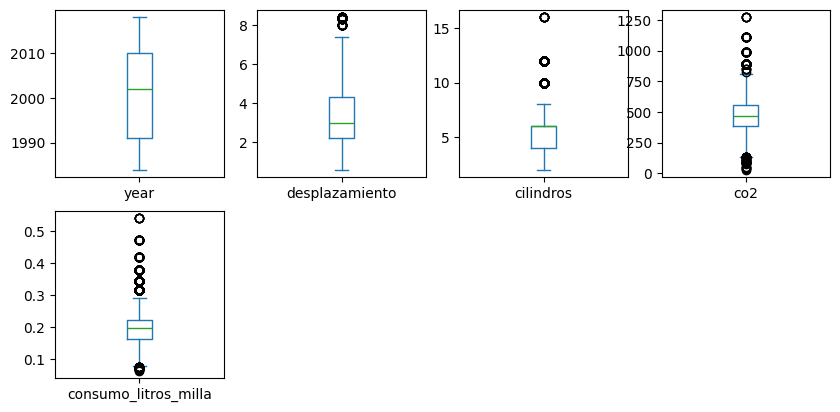

In [13]:
import matplotlib.pyplot as plt
data.plot(kind='box', subplots=True, layout=(4,4), sharex=False, sharey=False, figsize=(10,10))
plt.show()

In [14]:
# Funcion para hallar los outliers
def cap_outliers_iqr(data, var):
    Q1 = data[var].quantile(0.25)
    Q3 = data[var].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    data[var] = data[var].apply(lambda x: lim_sup if x > lim_sup else (lim_inf if x < lim_inf else x))
    return data

In [15]:
# Lista de variables
variables_con_outliers = ['desplazamiento', 'cilindros', 'co2', 'consumo_litros_milla']

# Aplicar la función a cada una
for var in variables_con_outliers:
    data = cap_outliers_iqr(data, var)

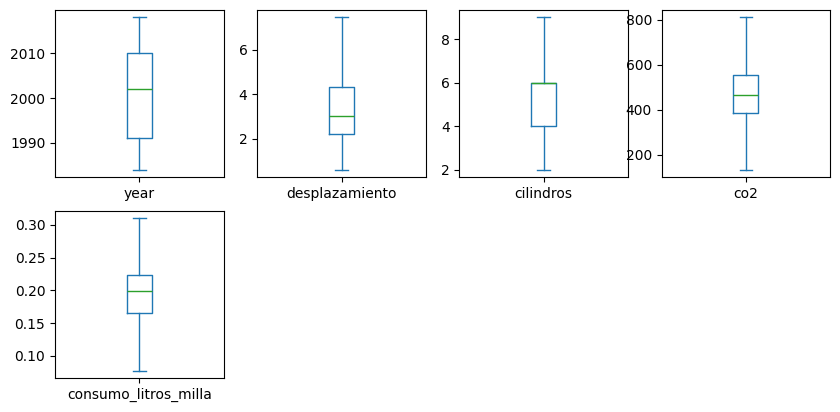

In [16]:
# Verificmaos los outliers
import matplotlib.pyplot as plt
data.plot(kind='box', subplots=True, layout=(4,4), sharex=False, sharey=False, figsize=(10,10))
plt.show()

#### Escalamiento para las variables numéricas

In [17]:
columnas_categoricas = data.select_dtypes(include=['object'])
columnas_numericas = data.select_dtypes(include=['int64', 'float64'])

In [18]:
### Separamos las variables numéricas
columnas_numericas.head()
columnas_numericas = columnas_numericas.drop('year', axis=1)

Es necesario visualizarlas, ya que puede suceder que hayan variables categoricas reconocidas como numero o variables numericas reconocidas como texto.

En este caso el escalado lo realizariamos en el co2, ya que las demás variables estan en un rango cercano.

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
columnas_numericas['co2'] = scaler.fit_transform(columnas_numericas[['co2']])
columnas_numericas.head(5)

,desplazamiento,cilindros,co2,consumo_litros_milla
0,2.5,4.0,0.576681,0.222671
1,4.2,6.0,0.814560,0.291185
2,2.5,4.0,0.625000,0.236588
3,4.2,6.0,0.814560,0.291185
4,3.8,6.0,0.625000,0.236588


#### Dumización para las variables categóricas

In [20]:
!pip install category_encoders

In [21]:
# Seleccionamos las variables categóricas:
columnas_categoricas.head()

,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo
0,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto
1,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto
2,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto
3,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto
4,Coches Medianos,dos,Automatica,Premium,grande,alto,alto


In [22]:
import category_encoders as ce

# Codificar solo las columnas categóricas dentro de X
encoder = ce.OneHotEncoder(cols=columnas_categoricas, use_cat_names=True)
columnas_categoricas = encoder.fit_transform(columnas_categoricas)

In [23]:
# Revisar resultado
columnas_categoricas.head()

,clase_tipo_Vehículos Especiales,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,clase_tipo_Deportivos,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Furgoneta,clase_tipo_Camionetas,traccion_tipo_dos,traccion_tipo_cuatro,...,consumo_tipo_alto,consumo_tipo_muy alto,consumo_tipo_bajo,consumo_tipo_muy bajo,consumo_tipo_moderado,co2_tipo_alto,co2_tipo_muy alto,co2_tipo_bajo,co2_tipo_muy bajo,co2_tipo_moderado
0,1,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0
1,1,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,1,0,0,0
2,1,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0
3,1,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,1,0,0,0
4,0,1,0,0,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0


### b.	Aplique un análisis de conglomerados no jerárquico por medio del método k-means y utilice el método del codo para determinar la cantidad de clusters adecuados. Compare los conglomerados formados y comente sobre las características que definen a estos.

In [24]:
X = pd.concat([columnas_categoricas, columnas_numericas], axis=1)

In [25]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4,n_init=25,random_state=123)
kmeans.fit(X=X)

KMeans(n_clusters=4, n_init=25, random_state=123)

In [26]:
clusters = kmeans.labels_
data["Cluster"] = clusters
data

,year,desplazamiento,cilindros,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla,Cluster
0,1984,2.5,4.0,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671,3
1,1984,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185,0
2,1985,2.5,4.0,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588,3
3,1985,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185,0
4,1987,3.8,6.0,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
36786,2015,1.0,3.0,244.000000,Coches pequeños,dos,Automatica,Premium,muy pequeño,muy bajo,muy bajo,0.105150,2
36787,2016,0.9,3.0,246.000000,Coches pequeños,dos,Automatica,Premium,muy pequeño,muy bajo,muy bajo,0.108155,2
36788,2016,0.9,3.0,255.000000,Coches pequeños,dos,Manual,Premium,muy pequeño,muy bajo,muy bajo,0.111336,2
36789,2017,0.9,3.0,248.000000,Coches pequeños,dos,Automatica,Premium,muy pequeño,muy bajo,muy bajo,0.108155,2


In [27]:
centroids = kmeans.cluster_centers_
print(centroids)
inertia = kmeans.inertia_
print(inertia)

[[ 7.12951432e-02  1.37686800e-01  2.73894770e-01  1.80339352e-01
   4.66998755e-02  6.06320050e-02  7.69769614e-02  1.52475093e-01
   6.76136364e-01  3.23863636e-01  7.43617684e-01  2.56382316e-01
   6.36674969e-01  3.16780822e-01  4.56102117e-02  9.33997509e-04
   3.86052304e-02  3.86519303e-01  5.70672478e-01  3.89165629e-04
   3.81382316e-03  2.08748443e-01  1.05541719e-01  1.97540473e-01
   2.88760897e-02  4.59293275e-01  2.12951432e-01  1.06475716e-01
   1.87422167e-01  1.90691158e-02  4.74081569e-01  3.41620486e+00
   5.99517435e+00  5.20365867e-01  2.06205430e-01]
 [ 5.67021749e-02  8.76608966e-02  2.14602752e-01  1.52685308e-01
   1.36484687e-02  9.92010652e-02  1.14403018e-01  2.61096316e-01
   6.61895251e-01  3.38104749e-01  8.21238349e-01  1.78761651e-01
   4.86018642e-01  3.67066134e-01  1.46582335e-01  3.32889481e-04
   3.30013794e-14  2.25366178e-01  3.10696849e-03  3.02813330e-14
   7.71526853e-01  1.97292499e-01  5.95650244e-01  1.50909898e-02
   3.80251386e-14  1.9196

In [28]:
from sklearn.metrics import euclidean_distances
distancias_centroides = euclidean_distances(centroids)
distancias_centroides

array([[0.        , 3.06805742, 3.2524797 , 2.56486851],
       [3.06805742, 0.        , 5.75726084, 5.3036057 ],
       [3.2524797 , 5.75726084, 0.        , 1.89316258],
       [2.56486851, 5.3036057 , 1.89316258, 0.        ]])

In [29]:
import numpy as np
list(zip(np.argmax(distancias_centroides,axis=1),
         np.max(distancias_centroides,axis=1)))


[(np.int64(2), np.float64(3.2524796996511296)),
 (np.int64(2), np.float64(5.757260835257086)),
 (np.int64(1), np.float64(5.757260835257086)),
 (np.int64(1), np.float64(5.303605698935502))]

In [30]:
def resumen_cluster(cluster_id):
    cluster = data[data["Cluster"] == cluster_id]

    # Asegurarse de que las columnas categóricas existen
    columnas_categoricas = [col for col in data.columns if 'tipo' in col]

    # Cálculo del resumen
    resumen = cluster[columnas_categoricas].mode().to_dict(orient='records')[0]
    resumen.update(cluster.mean(numeric_only=True).to_dict())
    resumen['cluster_id'] = cluster_id

    return resumen

resumen_cluster(3)

{'clase_tipo': 'Coches pequeños',
 'traccion_tipo': 'dos',
 'transmision_tipo': 'Automatica',
 'combustible_tipo': 'Normal',
 'tamano_motor_tipo': 'pequeño',
 'consumo_tipo': 'bajo',
 'co2_tipo': 'bajo',
 'year': 1996.733841778697,
 'desplazamiento': 2.228309203722854,
 'cilindros': 4.066571871768356,
 'co2': 429.696683713715,
 'consumo_litros_milla': 0.18280686990691972,
 'Cluster': 3.0,
 'cluster_id': 3}

In [31]:
def comparar_clusters(*cluster_ids):
    resumenes = []
    for cluster_id in cluster_ids:
        resumenes.append(resumen_cluster(cluster_id))
    return pd.DataFrame(resumenes).set_index("cluster_id").T

comparar_clusters(*np.unique(clusters))

cluster_id,0,1,2,3
clase_tipo,Coches pequeños,Camionetas,Coches pequeños,Coches pequeños
traccion_tipo,dos,dos,dos,dos
transmision_tipo,Automatica,Automatica,Automatica,Automatica
combustible_tipo,Normal,Normal,Normal,Normal
tamano_motor_tipo,mediano,muy grande,muy pequeño,pequeño
consumo_tipo,moderado,muy alto,muy bajo,bajo
co2_tipo,moderado,muy alto,muy bajo,bajo
year,2001.746965,2001.122059,2003.020578,1996.733842
desplazamiento,3.416205,5.275172,1.8776,2.228309
cilindros,5.995174,8.034731,3.973165,4.066572


#### Determinamos el numero apropiado de clusters

[329870.9464752531, 201808.5373290595, 152048.82664737615, 138776.00567622847, 129131.94870593204, 121816.43388969169, 115181.70671204438, 108615.92352899534, 104873.68733160335, 101661.61045703042, 98606.79078307348, 94863.61684951057, 91925.50993649171, 90208.14589605381, 87829.29073554346, 84756.93318866105, 82597.44667764801, 81984.7169027099, 79892.51676176106]


Text(0, 0.5, 'Inercia')

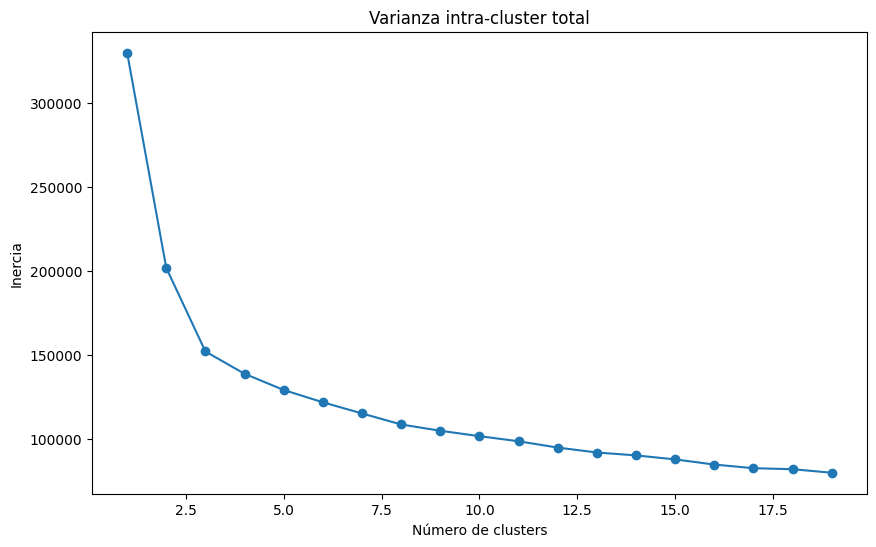

In [32]:
import matplotlib.pyplot as plt
range_n_clusters = range(1,20)
inercias = []
for i in range_n_clusters:
    kmeans = KMeans(n_clusters=i,n_init=20,random_state=123)
    kmeans.fit(X)
    inercias.append(kmeans.inertia_)
print(inercias)

fig, ax = plt.subplots(1,1,figsize=(10,6))
ax.plot(range_n_clusters,inercias,marker='o')
ax.set_title('Varianza intra-cluster total')
ax.set_xlabel('Número de clusters')
ax.set_ylabel('Inercia')

In [33]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, n_init=25, random_state=123)
kmeans.fit(X=X)

KMeans(n_clusters=4, n_init=25, random_state=123)

In [34]:
clusters = kmeans.labels_
data["Cluster"] = clusters
data

,year,desplazamiento,cilindros,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla,Cluster
0,1984,2.5,4.0,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671,3
1,1984,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185,0
2,1985,2.5,4.0,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588,3
3,1985,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185,0
4,1987,3.8,6.0,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
36786,2015,1.0,3.0,244.000000,Coches pequeños,dos,Automatica,Premium,muy pequeño,muy bajo,muy bajo,0.105150,2
36787,2016,0.9,3.0,246.000000,Coches pequeños,dos,Automatica,Premium,muy pequeño,muy bajo,muy bajo,0.108155,2
36788,2016,0.9,3.0,255.000000,Coches pequeños,dos,Manual,Premium,muy pequeño,muy bajo,muy bajo,0.111336,2
36789,2017,0.9,3.0,248.000000,Coches pequeños,dos,Automatica,Premium,muy pequeño,muy bajo,muy bajo,0.108155,2


In [35]:
from sklearn.decomposition import PCA
# Aplicar PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X)

# Crear DataFrame PCA con índice igual a X
pca_data = pd.DataFrame(pca_data, columns=["Componente 1", "Componente 2"], index=X.index)

# Añadir la columna de clusters con el mismo índice
pca_data_nombres = pca_data.copy()
pca_data_nombres["Cluster"] = kmeans.labels_


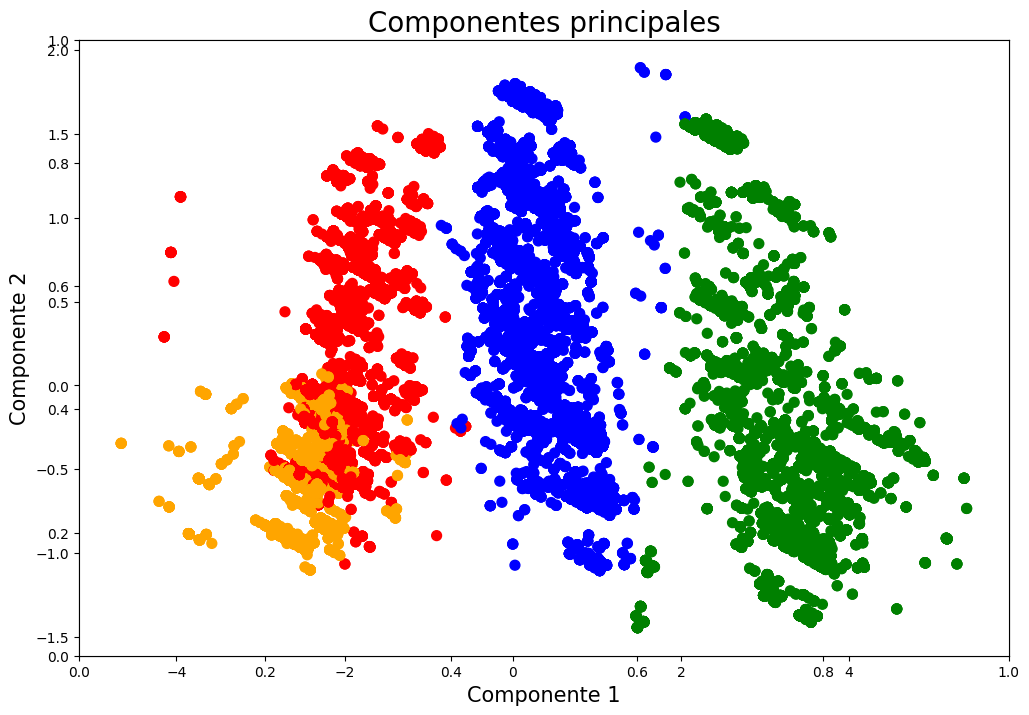

In [36]:
fig, ax = plt.subplots(1,1,figsize=(12,8))
ax = fig.add_subplot(1,1,1)
ax.set_xlabel('Componente 1',fontsize=15)
ax.set_ylabel('Componente 2',fontsize=15)
ax.set_title('Componentes principales',fontsize=20)
color_theme = np.array(["blue","green","orange","red","purple","yellow"])
ax.scatter(x=pca_data_nombres["Componente 1"],y=pca_data_nombres["Componente 2"],
           c=color_theme[pca_data_nombres["Cluster"]],s=50)
plt.show()


### c.	Calcule las principales medidas de evaluación interna e interprete los resultados obtenidos. También, calcule las principales medidas de evaluación externa tomando una cantidad de clusters de 8 y de referencia a la variable ‘clase_tipo’.

In [37]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Evaluación interna con K=8
kmeans_8 = KMeans(n_clusters=8, n_init=25, random_state=123)
labels_8 = kmeans_8.fit_predict(X)


# Cálculo de métricas
silhouette = silhouette_score(X, labels_8)
calinski = calinski_harabasz_score(X, labels_8)
davies = davies_bouldin_score(X, labels_8)

print("Silhouette Score:", silhouette)
print("Calinski-Harabasz Score:", calinski)
print("Davies-Bouldin Score:", davies)

Silhouette Score: 0.23623903856218104
Calinski-Harabasz Score: 10703.19220708149
Davies-Bouldin Score: 1.791625442389153


In [38]:
# Recuperar la clase original a partir de las columnas dummy
columnas_clase = [col for col in data.columns if 'clase_tipo' in col]
data['clase_tipo_original'] = data[columnas_clase].idxmax(axis=1)

In [39]:
from sklearn.metrics import adjusted_rand_score, homogeneity_completeness_v_measure

ari = adjusted_rand_score(data['clase_tipo_original'], labels_8)
homo, comp, v = homogeneity_completeness_v_measure(data['clase_tipo_original'], labels_8)

print("Adjusted Rand Index (ARI):", ari)
print("Homogeneity:", homo)
print("Completeness:", comp)
print("V-measure:", v)

Adjusted Rand Index (ARI): 0.0
Homogeneity: 1.0
Completeness: 0.0
V-measure: 0.0
